# Complete Intersection Calabi-Yau Threefolds

**What's in this notebook?** This notebook explains how CICY threefolds can be loaded.

(*Created:* Andreas Schachner, June 25, 2024)

## Imports

### General imports

In [1]:
import sys, os, warnings
import numpy as np
from tqdm.auto import tqdm
from functools import partial
from typing import Any, Callable, Sequence
from IPython.display import clear_output

import warnings
warnings.filterwarnings('ignore')

### JAX imports

In [2]:
from jax import jit, vmap
import jax 
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

### Plotting tools

In [3]:
import seaborn as sn
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap=sn.color_palette("viridis", as_cmap=True)

### Custom library for EFT

In [4]:
sys.path.append("./../../../")

import jaxvacua

## Type IIB compactifications on CICYs

### Introduction

Calabi-Yau (CY) threefolds play a central role in both algebraic geometry and theoretical physics, particularly in string theory, where they serve as compactification spaces for extra dimensions. Among the various constructions of Calabi--Yau threefolds, *complete intersection Calabi-Yau* (CICY) manifolds form a distinguished and well-studied class. These are defined as the zero loci of a set of polynomial equations within a higher-dimensional ambient space, typically a product of projective spaces.

The defining characteristic of a Calabi--Yau manifold is the vanishing of its first Chern class, ensuring the existence of a Ricci-flat Kähler metric. For a complete intersection in a toric or projective setting, this condition can be systematically realised through an appropriate choice of defining equations and embedding space.

CICY threefolds were systematically classified by Candelas, Green, and others in the late 1980s (see [Nucl.Phys.B 298 (1988) 493](https://inspirehep.net/literature/21761) and [Class.Quant.Grav. 6 (1989) 105-124](https://inspirehep.net/literature/251839)), leading to an important dataset of manifolds that have been extensively used in string compactifications. These spaces are typically described by configuration matrices, encoding the structure of the defining equations and their embedding spaces.

Beyond their mathematical interest, CICY manifolds provide fertile ground for model building in string phenomenology. Their relatively simple construction makes them amenable to computational methods, and their moduli spaces are crucial for understanding physical properties such as Yukawa couplings and gauge symmetries.

In what follows, we introduce the basic formalism of CICY manifolds, outline their classification, and discuss their role in physics. We begin by reviewing the mathematical framework necessary for their construction.


The original list of favorable CICYs of [Nucl.Phys.B 298 (1988) 493](https://inspirehep.net/literature/21761) was expanded to 7,842 in [1708.07907](https://arxiv.org/pdf/1708.07907) (see also [2112.12106](https://arxiv.org/pdf/2112.12106)) by finding new favorable descriptions.
After removing redundancies, there are 25 distinct geometries (24 hypersurfaces in an ambient product of two del Pezzo surfaces plus the Schoen manifold) for which no such favorable representative exists. 
Out of the 7,842 favorable geometries, one obtains 4,874 **Kähler favorable** CICYs whose Kähler cones are inherited from the ambient space corresponding to the entire positive orthant. After removing redundancies, there are 4,525 geometries of which 107 have $h^{1,1}\geq 10$.

For the non-Kähler favorable CICYs, we can obtain the Kähler cone as follows. We compute the Mori cones generated by the rays obtained from GV invariants. The dual cone corresponds to an approximation of the Kähler cone. We restrict to $h^{1,1}\leq 9$ for which GV invariants up to degree 10 have been obtained in [2101.07272](https://arxiv.org/abs/2101.07272). We use this list of GV invariants to obtain approximations of the corresponding Kähler cones for all favorable CICYs that are not Kähler favorable. We find 1,637 CICYs after removing redundancies as mentioned before.
Overall, there are 1,033 favorable CICYs with $h^{1,1}\geq 10$ for which we have not computed any GV invariants.

### CICY data

To start with, we provide

In [5]:
CICYs = jaxvacua.cicy_prepot.load_cicy_data()
CICYs[CICYs["h11"]==1]

,CICY ID,h11,h12,favorable,Kahler favorable,product,equivalence
7860,7861,1,65,True,True,False,-1
7877,7878,1,73,True,True,False,-1
7878,7879,1,73,True,True,False,-1
7888,7889,1,89,True,True,False,-1
7889,7890,1,101,True,True,False,-1


Here, the individual entries
* `CICY ID`: Standard ID for the CICYs.
* `h11` and `h12`: Hodge numbers of the Calabi-Yau.
* `favorable`: Whether or not the CY can be favorably embedded (obtained from [1708.07907](https://arxiv.org/pdf/1708.07907)).
* `Kahler favorable`: Whether or not the CY is Kahler favorable (obtained from [1708.07907](https://arxiv.org/pdf/1708.07907)).
* `product`: Whether the ambient space is a product space (obtained from [1708.07907](https://arxiv.org/pdf/1708.07907)).
* `equivalence`: Equivalence to another CICY (obtained from [2101.07272](https://arxiv.org/abs/2101.07272)).

### Loading CICY models

#### The mirror quintic

As a first example, we can load the mirror quintic as follows:

In [6]:
model = jaxvacua.flux_sector(model_ID = 7890, model_type="CICY", maximum_degree=10)
model

GW invariants not available. Use GVs instead for computations!


Flux sector for mirror quintic with h12=1 complex structure moduli in the LCS limit.

We can call the topological data of `model` through

In [7]:
(f"intersection numbers: {model.periods.mirror_intersection_numbers.astype(int)}",
f"Euler character: {model.periods.chi}",
f"Second Chern class: {model.periods.mirror_second_chern_class}",
f"Leading order GV invariants: {model.periods.GV_inv[:4].astype(int)}")

('intersection numbers: [[[5]]]',
 'Euler character: -200.0',
 'Second Chern class: [50.]',
 'Leading order GV invariants: [        2875       609250    317206375 242467530000]')

We can also load some additional information about the chosen CICY by calling:

In [8]:
model.periods.extra_data

,CICY ID,h11,h12,favorable,Kahler favorable,product,equivalence
7889,7890,1,101,True,True,False,-1


Let us test a few explicit solutions for the F-term conditions $D_zW=D_\tau W=0$:

In [9]:
fluxes = jnp.array([[ 13, -14,  -3,  -1,  -4,  -4,   5,  -2],
                    [-31,   8,  -3,  -1,   7,   2,  -2,   1],
                    [ 13, -17,   2,   0,  -4,  -8,   2,  -2],
                    [ -4,  30,   1,   5,   0,  -9,  -2,   1],
                    [-23, -10,   4,  -4,  -1,  -1,  -4,   0]])

moduli = jnp.array([[-0.33957014+1.14038076j],
                    [ 0.16328305+1.83965502j],
                    [ 0.08654968+1.54423725j],
                    [ 0.11764233+1.50070858j],
                    [ 0.11973228+1.16350409j]])

tau = jnp.array([-0.08966074+2.72528655j, -0.02904458+2.57532019j, 0.4228709 +2.02225755j, 0.27414269+1.80896j, -1.37897558+4.3308653j])

We can evaluate $D_zW, D_\tau W$ as well as $W_0$ and $N_{\mathrm{flux}}$

In [10]:
DW = jnp.abs(vmap(model.DW)(moduli,jnp.conj(moduli),tau,jnp.conj(tau),fluxes))
W0 = vmap(model.superpotential_gauge_invariant)(moduli,tau,fluxes)
Nflux = vmap(model.tadpole)(fluxes)

print(r"Residual for the F-term conditions DW: ",np.sum(DW,axis=1))

Residual for the F-term conditions DW:  [1.03637148e-07 2.27383707e-07 1.00354671e-07 9.01072417e-08
 3.82761050e-07]


We plot the solutions below

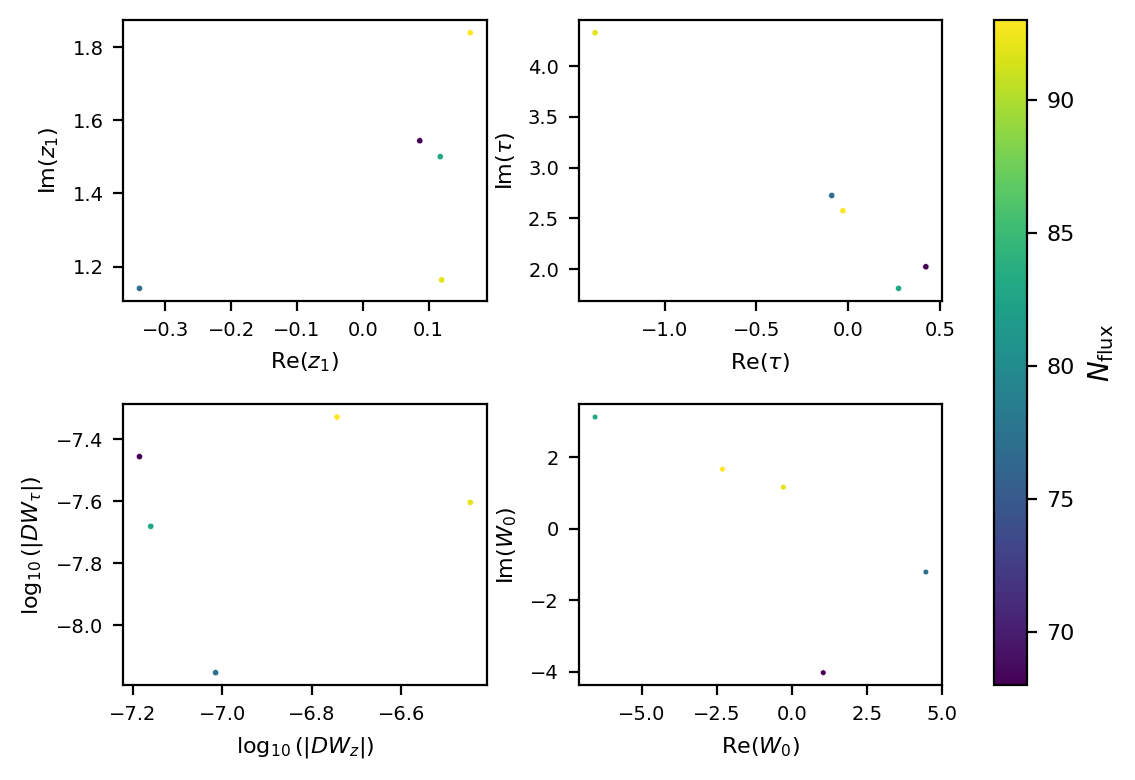

In [11]:
fig, ax = plt.subplots(2, 2,dpi=200,figsize=(6,4))

fs = 8

sn.scatterplot(x=moduli[:,0].real,y=moduli[:,0].imag,s=5,ax=ax[0,0],hue = Nflux,palette=cmap)
ax[0,0].legend_.remove()
ax[0,0].set_xlabel(r"Re$(z_1)$",fontsize = fs)
ax[0,0].set_ylabel(r"Im$(z_1)$",fontsize = fs)


sn.scatterplot(x=tau.real,y=tau.imag,s=5,ax=ax[0,1],hue = Nflux,palette=cmap)
ax[0,1].legend_.remove()
ax[0,1].set_xlabel(r"Re$(\tau)$",fontsize = fs)
ax[0,1].set_ylabel(r"Im$(\tau)$",fontsize = fs)


sn.scatterplot(x=np.log10(DW[:,0]),y=np.log10(DW[:,1]),s=5,ax=ax[1,0],hue = Nflux,palette=cmap)
ax[1,0].legend_.remove()
ax[1,0].set_xlabel(r"$\log_{10}(|DW_z|)$",fontsize = fs)
ax[1,0].set_ylabel(r"$\log_{10}(|DW_\tau|)$",fontsize = fs)


sn.scatterplot(x=W0.real,y=W0.imag,s=4,ax=ax[1,1],hue = Nflux,palette=cmap)
#ax[1,1].set_xlim(-5,5)
#ax[1,1].set_ylim(0,10)
ax[1,1].legend_.remove()
ax[1,1].set_xlabel(r"Re$(W_0)$",fontsize = fs)
ax[1,1].set_ylabel(r"Im$(W_0)$",fontsize = fs)
#ax[1,1].set_title("Superpotential",fontsize=10)

for i in range(2):
    for j in range(2):
        ax[i,j].tick_params(labelsize=fs-1) 

plt.tight_layout()

norm = plt.Normalize(min(Nflux),max(Nflux))
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
clb = fig.colorbar(sm, label=r"$N_{\mathrm{flux}}$", ax=ax.ravel().tolist())

clb.ax.tick_params(labelsize=fs)

plt.show()

#### Calabi–Yau threefold of Hulek–Verrill

Another Calabi–Yau threefold is that of Hulek–Verrill recently studied in https://arxiv.org/pdf/2404.12422.
It has $h^{1,2}=5$ and $h^{1,1}=45$ and can be loaded as follows:

In [12]:
model = jaxvacua.flux_sector(model_ID = 7447, Q=100,model_type="CICY",maximum_degree=10)
model

GW invariants not available. Use GVs instead for computations!


Flux sector for Hulek–Verrill (2404.12422) with h12=5 complex structure moduli in the LCS limit.

As above, we can look at the model data as follows:

In [13]:
(f"intersection numbers: {model.periods.mirror_intersection_numbers.astype(int)}",
f"Euler character: {model.periods.chi}",
f"Second Chern class: {model.periods.mirror_second_chern_class}",
f"Leading order GV invariants: {model.periods.GV_inv[:10].astype(int)}")

('intersection numbers: [[[0 0 0 0 0]\n  [0 0 2 2 2]\n  [0 2 0 2 2]\n  [0 2 2 0 2]\n  [0 2 2 2 0]]\n\n [[0 0 2 2 2]\n  [0 0 0 0 0]\n  [2 0 0 2 2]\n  [2 0 2 0 2]\n  [2 0 2 2 0]]\n\n [[0 2 0 2 2]\n  [2 0 0 2 2]\n  [0 0 0 0 0]\n  [2 2 0 0 2]\n  [2 2 0 2 0]]\n\n [[0 2 2 0 2]\n  [2 0 2 0 2]\n  [2 2 0 0 2]\n  [0 0 0 0 0]\n  [2 2 2 0 0]]\n\n [[0 2 2 2 0]\n  [2 0 2 2 0]\n  [2 2 0 2 0]\n  [2 2 2 0 0]\n  [0 0 0 0 0]]]',
 'Euler character: -80.0',
 'Second Chern class: [24. 24. 24. 24. 24.]',
 'Leading order GV invariants: [ 24  24  24  24  24  24 112  24  24  24]')